[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ Ready! Paste your data in the next cell.

📂 Upload your CSV file from Kaggle:
Click 'Choose Files' below


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


Saving archive.zip to archive (2).zip

✅ Uploaded: archive (2).zip

📊 Dataset loaded: 568454 rows, 10 columns

Column names: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

First 5 rows:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3     

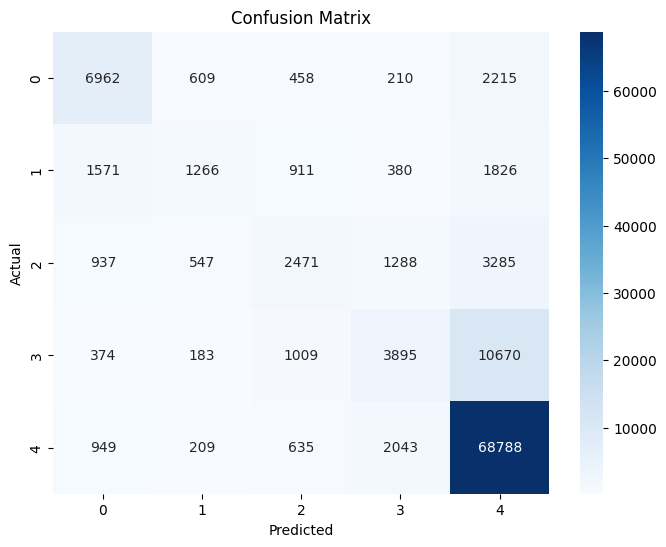

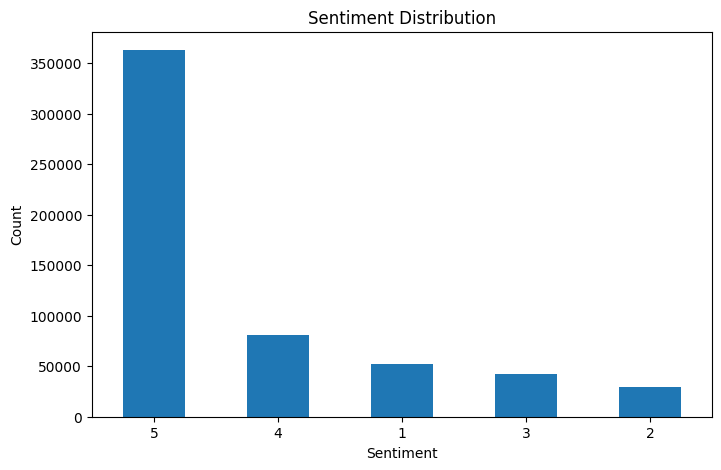


✅ MODEL TRAINED!

TEST NEW REVIEWS

📝 This product is amazing, I love it!


AttributeError: 'numpy.int64' object has no attribute 'upper'

In [3]:
# ============================================
# SENTIMENT ANALYSIS - READY FOR YOUR DATA
# ============================================

# PART 1: INSTALL AND IMPORT
!pip install -q pandas numpy scikit-learn nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import re
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


print("✅ Ready! Paste your data in the next cell.")

# ============================================
# PART 2: LOAD YOUR DATA (YOU WILL PASTE HERE)
# ============================================

# OPTION A: Upload CSV file from Kaggle
# Run this cell, then upload your file
from google.colab import files

print("\n📂 Upload your CSV file from Kaggle:")
print("Click 'Choose Files' below")
uploaded = files.upload()

# Get the filename
import os
filename = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {filename}")

# ============================================
# PART 3: READ AND CHECK DATA
# ============================================

# Read the CSV
df = pd.read_csv(filename)

print(f"\n📊 Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

# ============================================
# PART 4: SELECT COLUMNS (EDIT THESE)
# ============================================

# IMPORTANT: Change these to match your CSV columns
# Example: If your columns are 'review' and 'sentiment', use:
# TEXT_COLUMN = 'review'
# LABEL_COLUMN = 'sentiment'

# Common Kaggle column names:
# IMDB: 'review' and 'sentiment'
# Amazon: 'Text' and 'Score'
# Twitter: 'text' and 'sentiment'

TEXT_COLUMN = 'Text'    # <-- CHANGE THIS TO YOUR TEXT COLUMN
LABEL_COLUMN = 'Score'  # <-- CHANGE THIS TO YOUR LABEL COLUMN

# Check if columns exist
if TEXT_COLUMN not in df.columns or LABEL_COLUMN not in df.columns:
    print(f"\n⚠️ ERROR: Columns not found!")
    print(f"Your columns are: {list(df.columns)}")
    print(f"Please edit TEXT_COLUMN and LABEL_VARIABLE above.")
else:
    print(f"\n✅ Using columns: '{TEXT_COLUMN}' (text) and '{LABEL_COLUMN}' (label)")
    print(f"\nLabel distribution:")
    print(df[LABEL_COLUMN].value_counts())

# ============================================
# PART 5: TEXT PREPROCESSING
# ============================================

def clean_text(text):
    """Clean and preprocess text"""
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    return ' '.join(tokens)

# Apply cleaning
print("\n🧹 Cleaning text...")
df['cleaned_text'] = df[TEXT_COLUMN].apply(clean_text)

# Remove empty rows
df = df[df['cleaned_text'].str.len() > 0]

print(f"✅ Cleaned {len(df)} reviews")

# ============================================
# PART 6: TRAIN MODEL
# ============================================

# Prepare data
X = df['cleaned_text']
y = df[LABEL_COLUMN]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Vectorize
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train
print("\n🤖 Training Logistic Regression...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Predict
predictions = model.predict(X_test_vec)

# ============================================
# PART 7: EVALUATE
# ============================================

print("\n" + "="*50)
print("RESULTS")
print("="*50)

accuracy = accuracy_score(y_test, predictions)
print(f"\n🎯 ACCURACY: {accuracy:.2f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, predictions))

# ============================================
# PART 8: VISUALIZE
# ============================================

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Label distribution
plt.figure(figsize=(8, 5))
df[LABEL_COLUMN].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

print("\n✅ MODEL TRAINED!")

# ============================================
# PART 9: TEST NEW REVIEWS
# ============================================

def predict_new(text):
    """Predict sentiment of new text"""
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    pred = model.predict(vectorized)[0]
    conf = max(model.predict_proba(vectorized)[0])
    return pred, conf

print("\n" + "="*50)
print("TEST NEW REVIEWS")
print("="*50)

test_reviews = [
    "This product is amazing, I love it!",
    "Terrible quality, complete waste of money",
    "It's okay, average product"
]

for review in test_reviews:
    sentiment, confidence = predict_new(review)
    print(f"\n📝 {review}")
    print(f"   → {sentiment.upper()} (confidence: {confidence:.2f})")

print("\n" + "="*50)
print("✅ PROJECT COMPLETE!")
print("="*50)